# Leaf Segmentation Test Notebook

This notebook iterates through three leaf images (one for each veg type), visualizes each channel in 3 color spaces (RGB, CIELAB, HSV) as individual images, and then applies PCA and Otsu thresholding separately for each color space. It generates scree plots of explained variance, performs Otsu's thresholding, cleans up noise using morphology, and outputs every step (PCA projection, thresholded mask, contour overlay) as an individual image.

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

### Select Representative Leaf Images

We select one image from each vegetable type directory (`veg_1`, `veg_2`, `veg_3`).

In [20]:
img_paths = [
    'leaf-image/veg_1/IMG_7993.JPG',
    'leaf-image/veg_2/IMG_7995.JPG',
    'leaf-image/veg_3/IMG_7997.JPG'
]

for path in img_paths:
    if os.path.exists(path):
        print(f"Verified image: {path}")
    else:
        print(f"Error: {path} not found.")

Verified image: leaf-image/veg_1/IMG_7993.JPG
Verified image: leaf-image/veg_2/IMG_7995.JPG
Verified image: leaf-image/veg_3/IMG_7997.JPG


### Processing Pipeline

For each leaf image:
1. **Visualize Channels in 3 Color Spaces**: Plot R, G, B, L*, a*, b*, H, S, V channels as individual images.
2. **PCA & Otsu per Color Space**:
   - For each color space (RGB, CIELAB, HSV):
     - Stack the 3 channels into a 3D feature matrix.
     - Compute PCA using `cv2.PCACompute2` and project onto PC1.
     - Perform **polarity correction** by correlating PC1 with the CIELAB $a^*$ channel.
     - Scale PC1 to 0-255.
     - Plot a scree chart of explained variance for the 3 components.
     - Perform Otsu's thresholding followed by morphological opening and closing.
     - Detect external contours and display the PC1 projection, the Otsu binary mask, and final contours overlaid on the original image as individual images.


PROCESSING IMAGE 1: leaf-image/veg_1/IMG_7993.JPG

--- Channel Visualizations for Image 1 ---


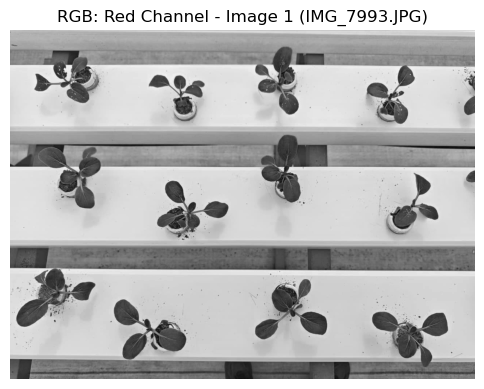

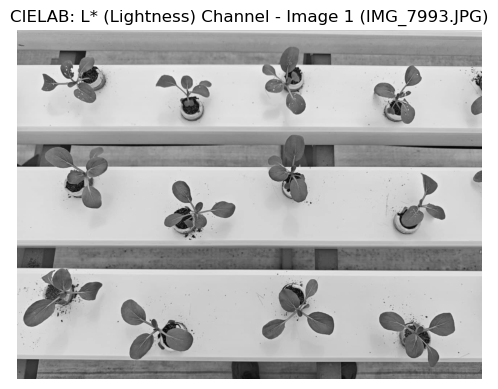

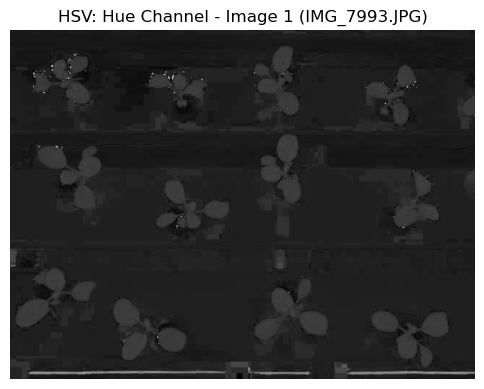

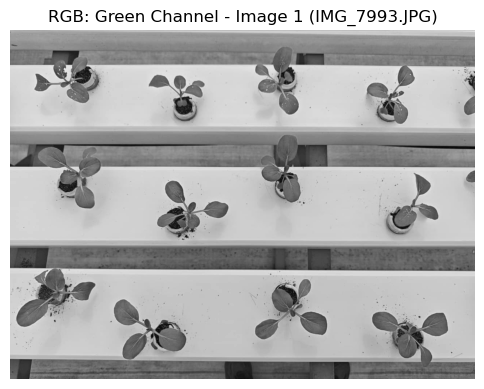

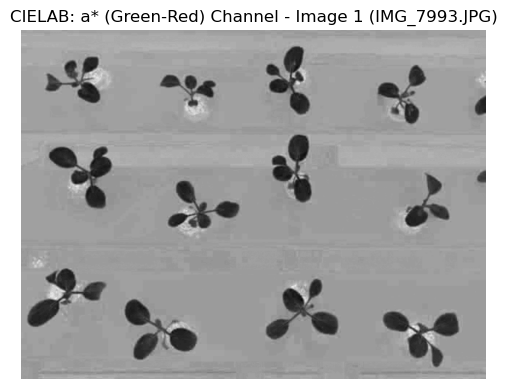

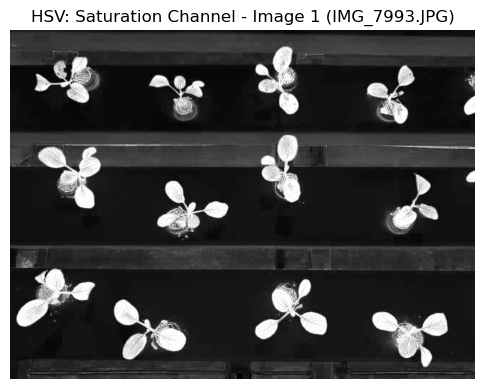

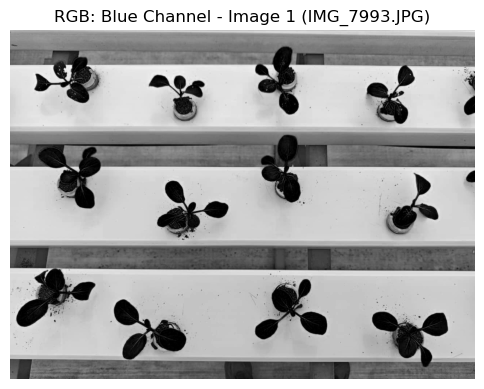

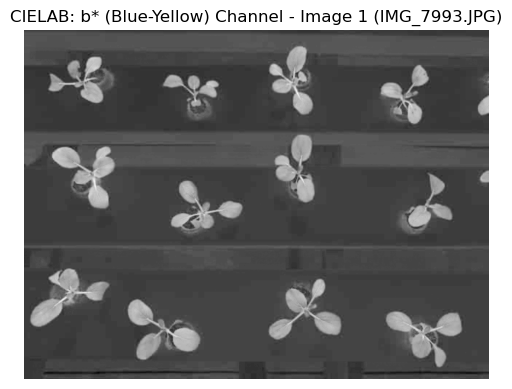

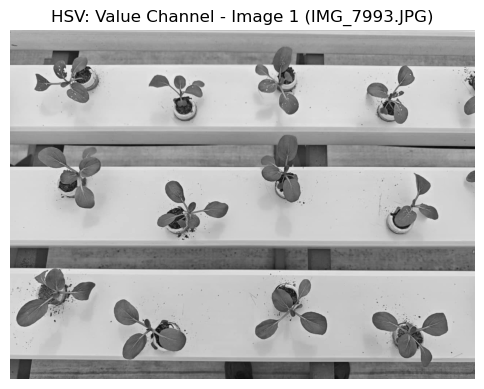


----------------------------------------
Color Space: RGB (Image 1)
----------------------------------------


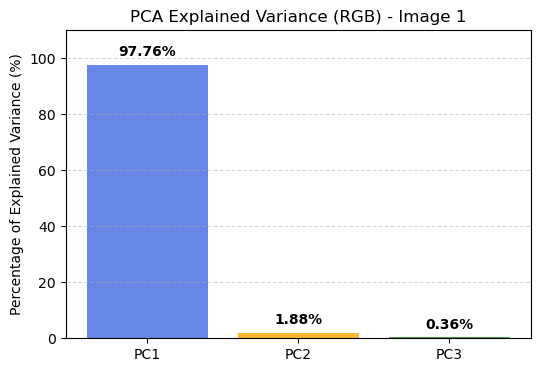

[RGB] Otsu threshold value: 102.0


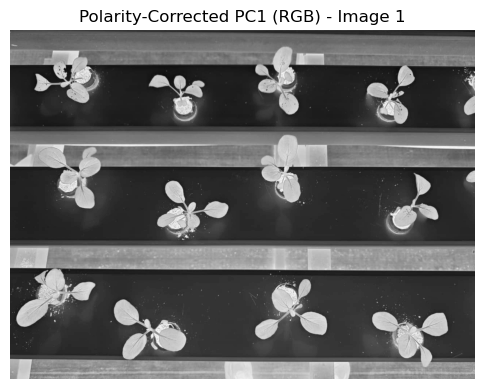

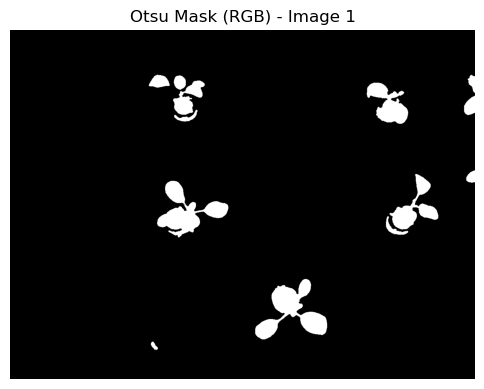

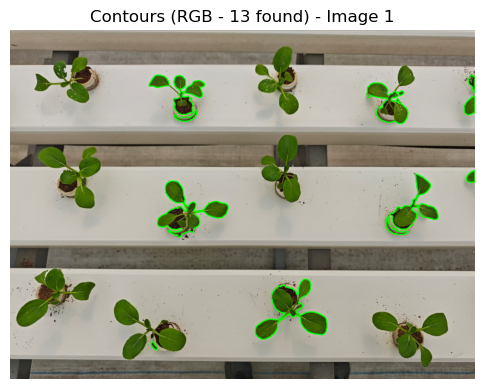


----------------------------------------
Color Space: CIELAB (Image 1)
----------------------------------------


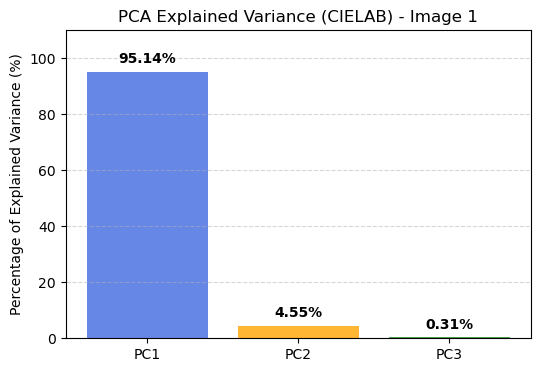

[CIELAB] Otsu threshold value: 95.0


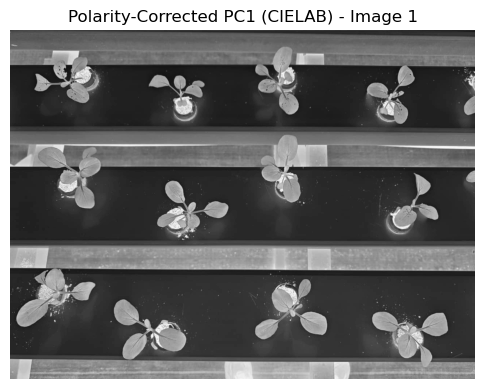

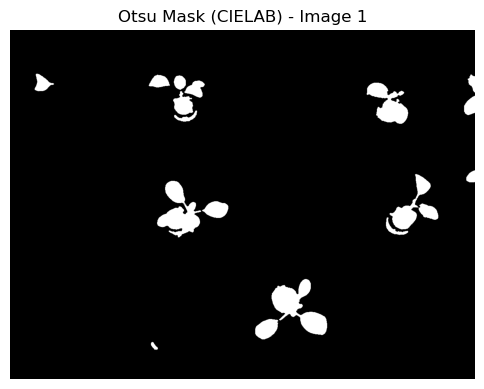

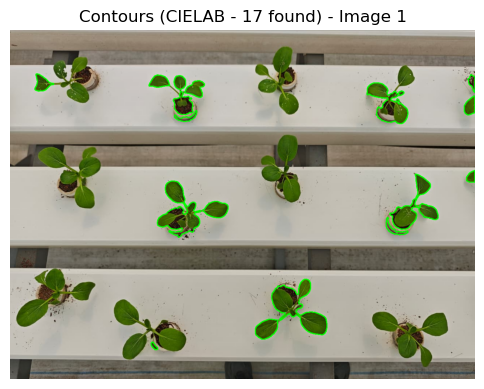


----------------------------------------
Color Space: HSV (Image 1)
----------------------------------------


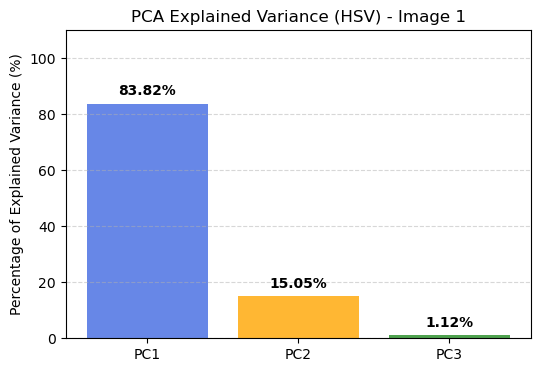

[HSV] Otsu threshold value: 118.0


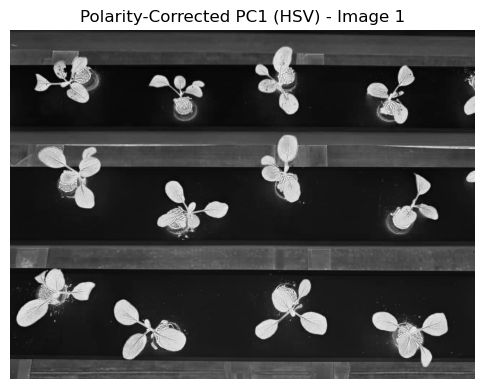

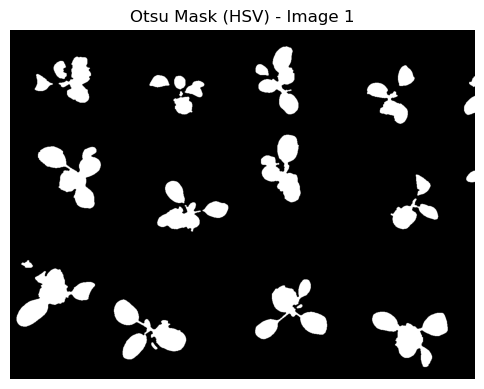

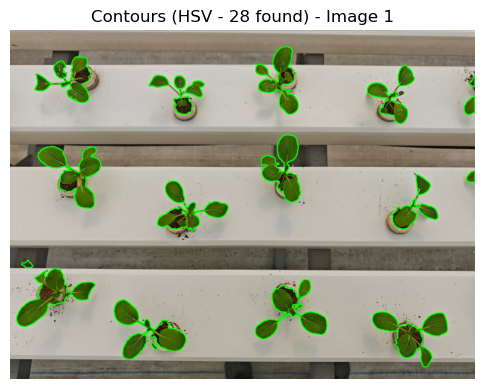


PROCESSING IMAGE 2: leaf-image/veg_2/IMG_7995.JPG

--- Channel Visualizations for Image 2 ---


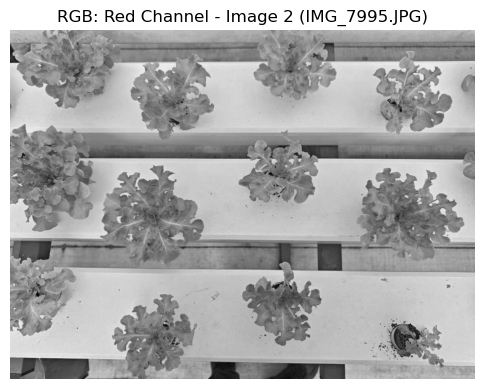

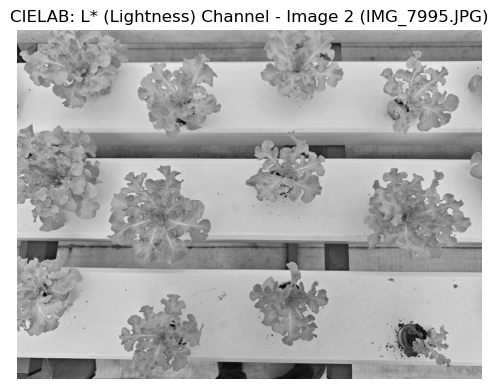

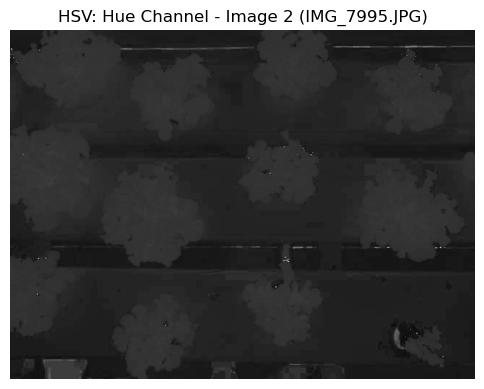

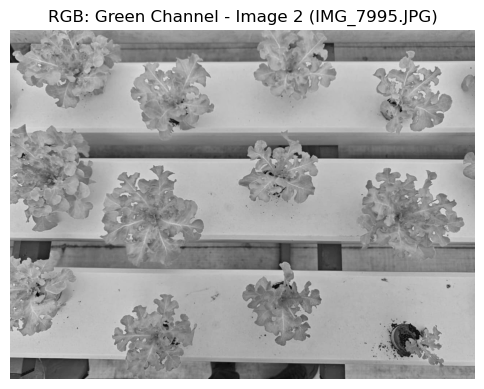

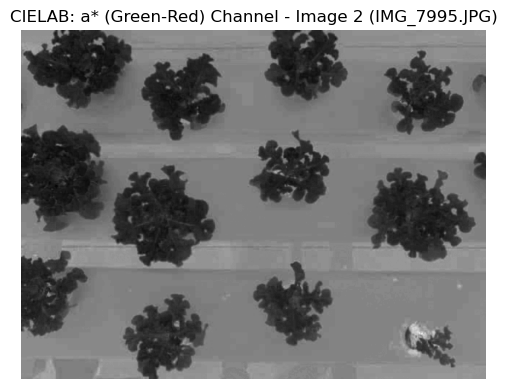

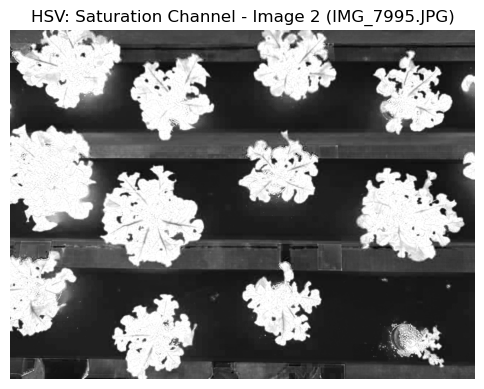

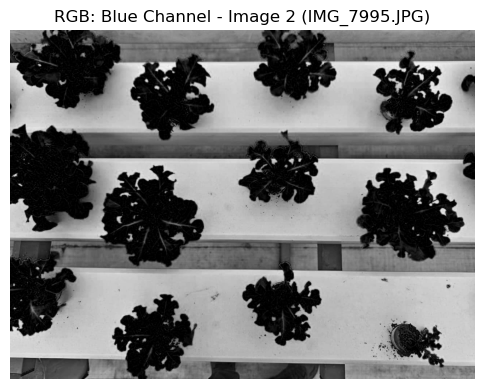

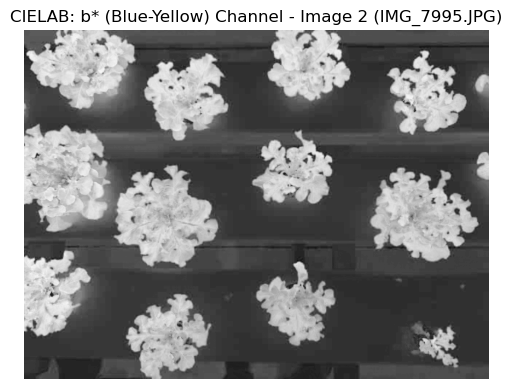

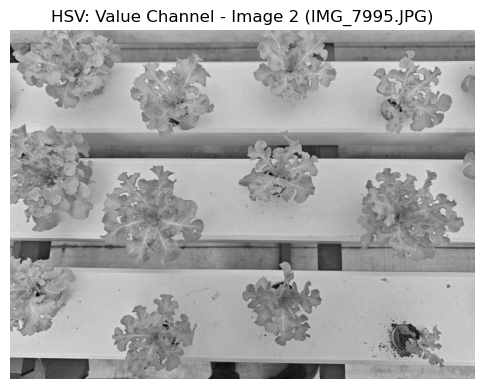


----------------------------------------
Color Space: RGB (Image 2)
----------------------------------------


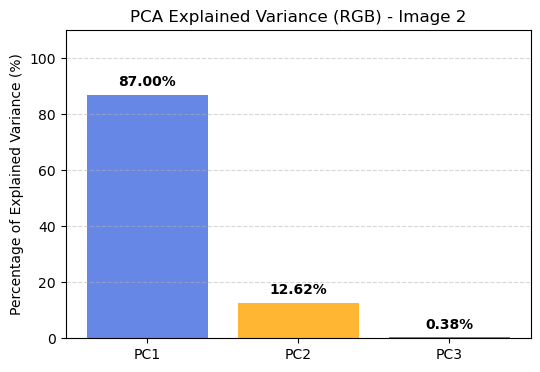

[RGB] Otsu threshold value: 113.0


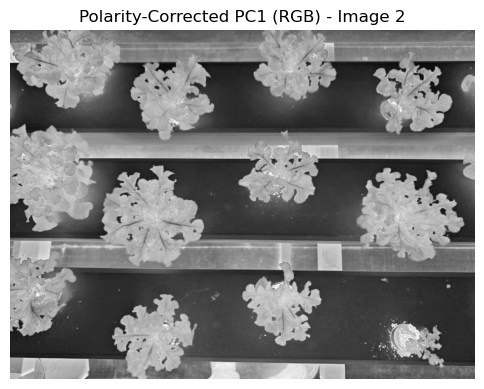

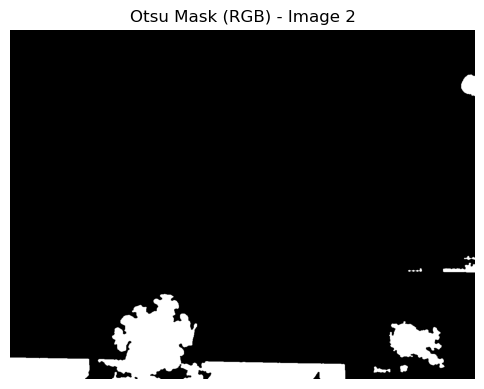

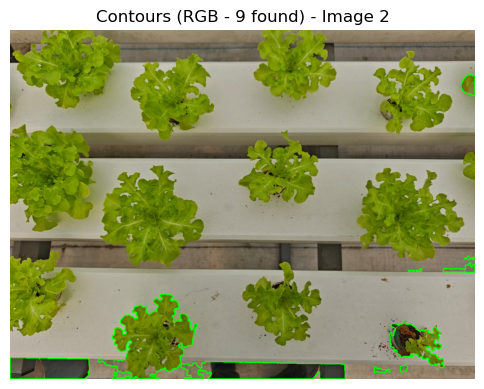


----------------------------------------
Color Space: CIELAB (Image 2)
----------------------------------------


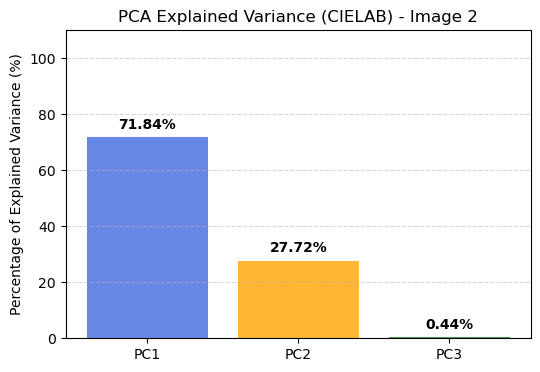

[CIELAB] Otsu threshold value: 95.0


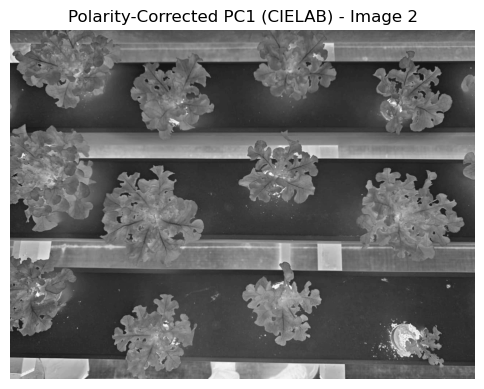

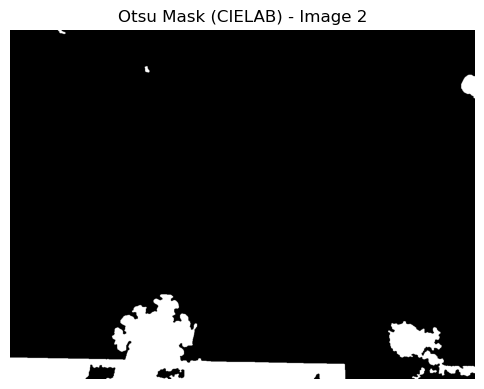

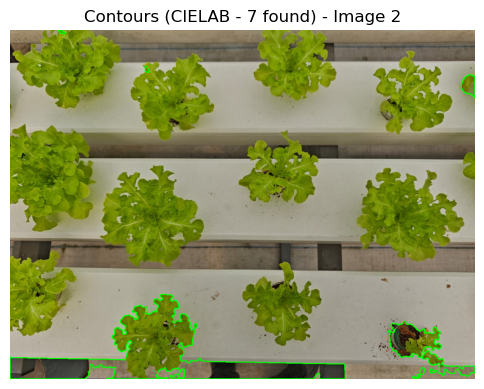


----------------------------------------
Color Space: HSV (Image 2)
----------------------------------------


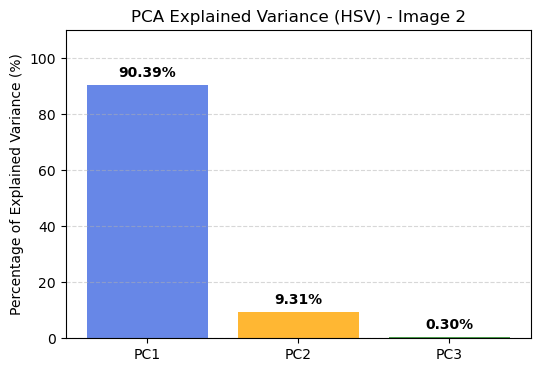

[HSV] Otsu threshold value: 132.0


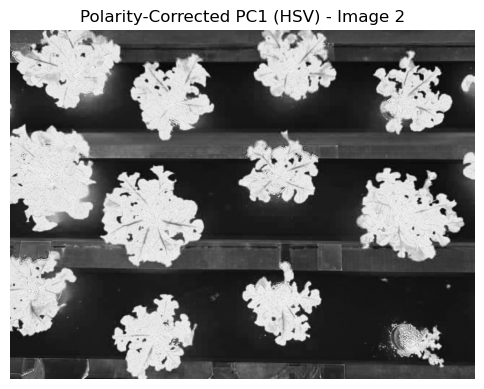

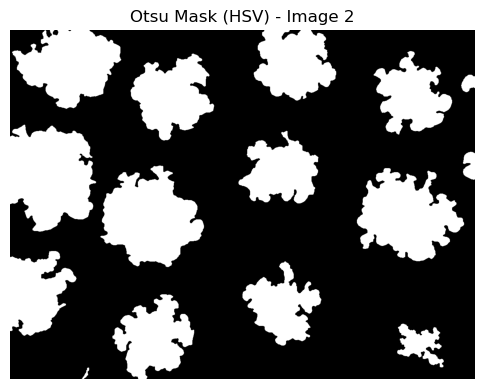

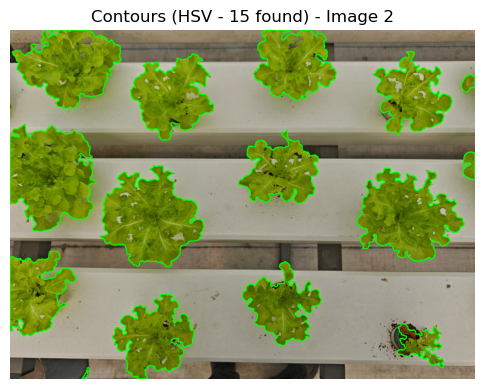


PROCESSING IMAGE 3: leaf-image/veg_3/IMG_7997.JPG

--- Channel Visualizations for Image 3 ---


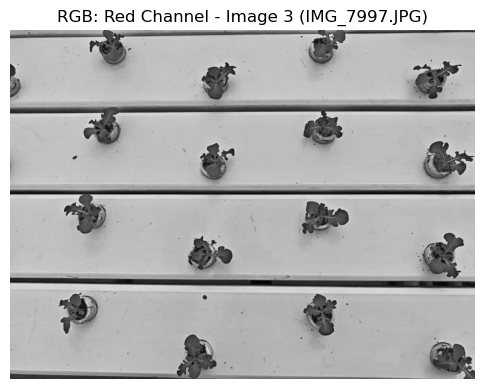

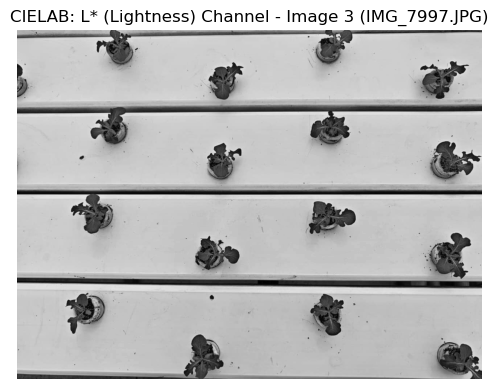

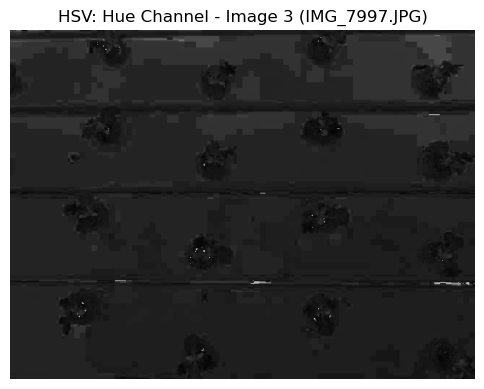

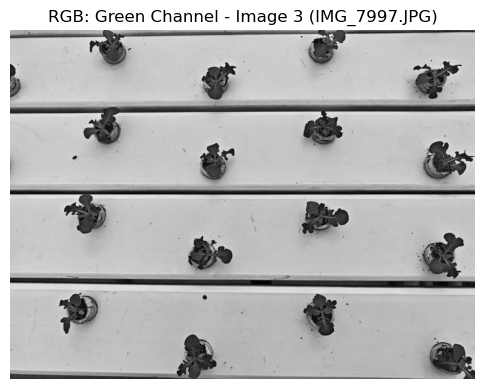

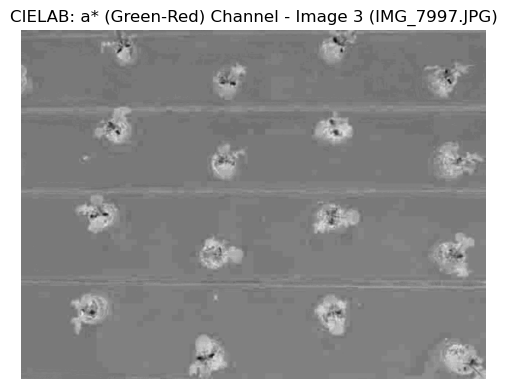

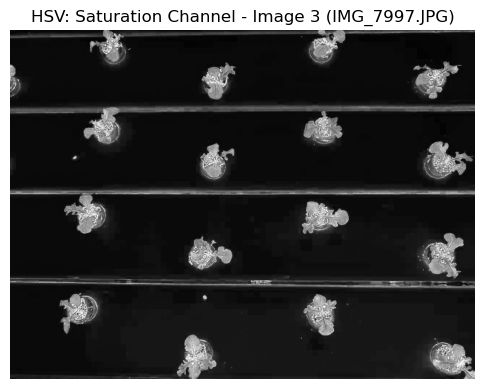

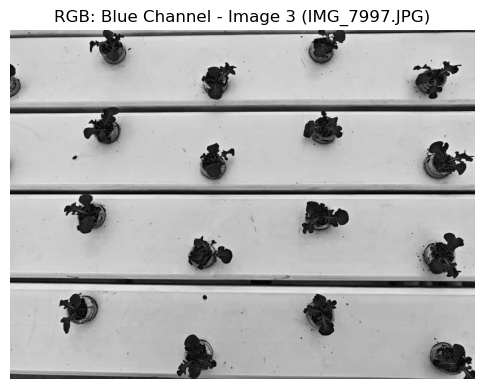

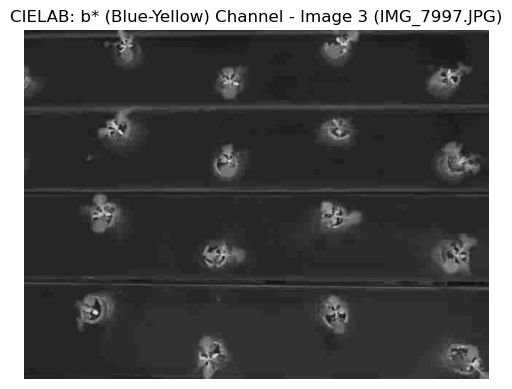

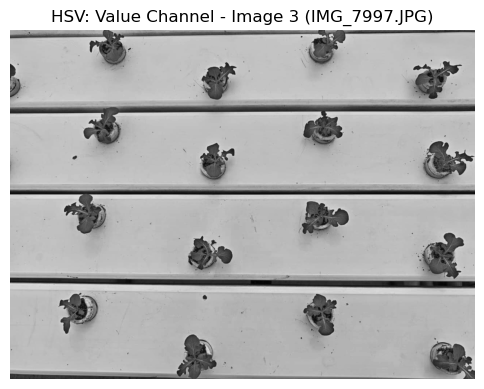


----------------------------------------
Color Space: RGB (Image 3)
----------------------------------------


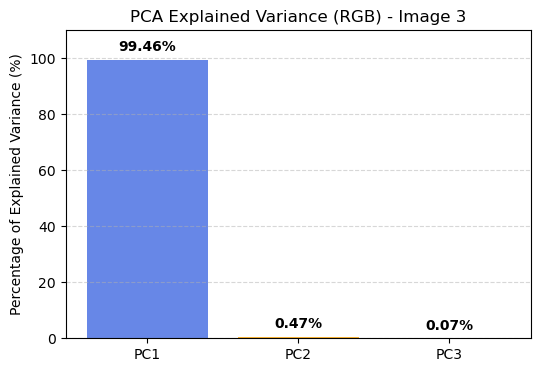

[RGB] Otsu threshold value: 122.0


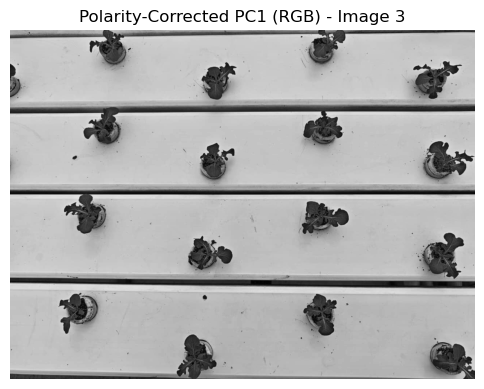

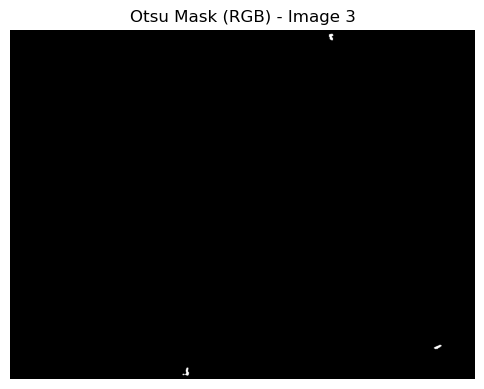

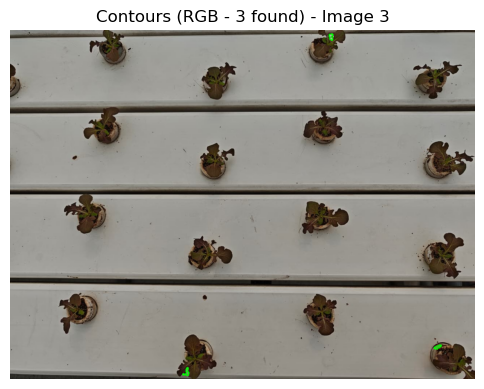


----------------------------------------
Color Space: CIELAB (Image 3)
----------------------------------------


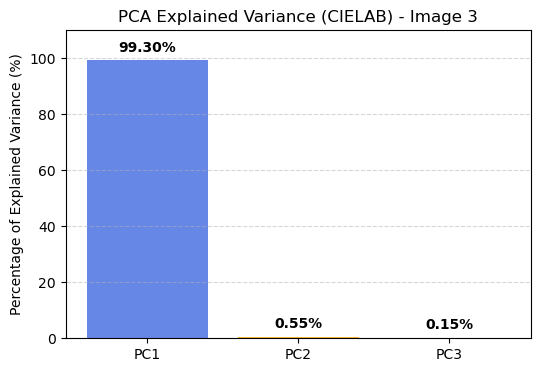

[CIELAB] Otsu threshold value: 126.0


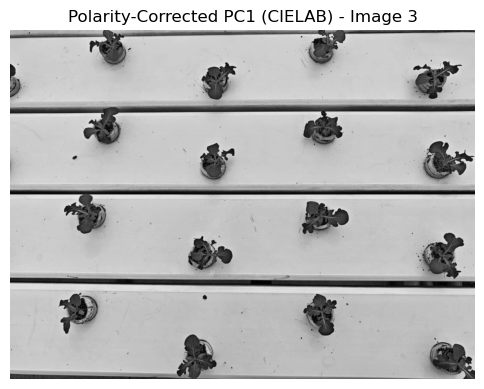

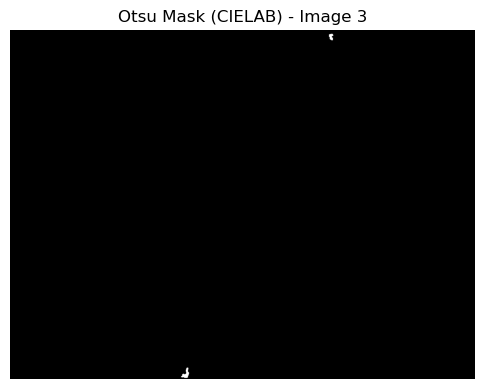

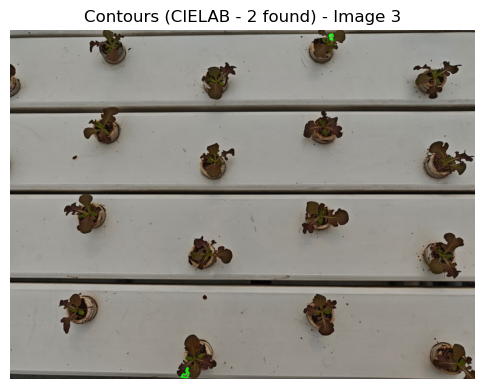


----------------------------------------
Color Space: HSV (Image 3)
----------------------------------------


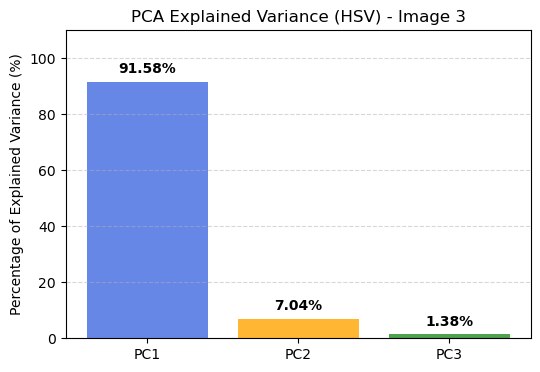

[HSV] Otsu threshold value: 165.0


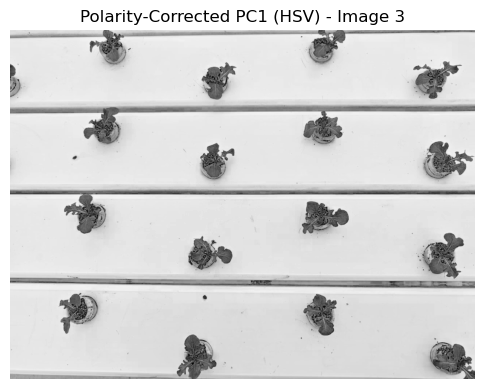

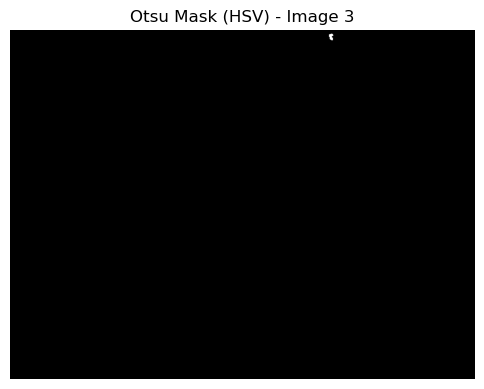

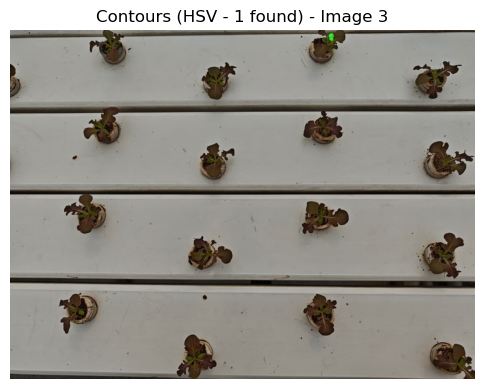

In [21]:
    # Define color spaces (including lightness)
    color_spaces = {
        'RGB': lambda rgb: cv2.split(rgb),
        'CIELAB': lambda rgb: cv2.split(cv2.cvtColor(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2Lab)),
        'HSV': lambda rgb: cv2.split(cv2.cvtColor(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV))
    }
    
    for space_name, extract_func in color_spaces.items():
        print(f"\n" + "-"*40)
        print(f"Color Space: {space_name} (Image {idx+1})")
        print("-"*40)
        
        # Stack channels into feature representation
        channels = extract_func(img_rgb)
        
        # Standardize channels before PCA to prevent lightness dominance
        flats = []
        for ch in channels:
            ch_f = ch.astype(np.float32)
            std = ch_f.std()
            ch_norm = (ch_f - ch_f.mean()) / (std if std > 1e-8 else 1.0)
            flats.append(ch_norm.reshape(-1, 1))
        features = np.hstack(flats)
        
        # Perform PCA
        mean, eigenvectors, eigenvalues = cv2.PCACompute2(features, mean=None)
        projected = cv2.PCAProject(features, mean, eigenvectors)
        pc1 = projected[:, 0].reshape(channels[0].shape)
        
        # Polarity Correction using the color space's own reference channel
        ref_channel = channels[1]  # RGB: Green, CIELAB: a*, HSV: Saturation
        correlation = np.corrcoef(pc1.ravel(), ref_channel.ravel())[0, 1]
        if space_name == 'CIELAB':
            if correlation > 0:
                pc1 = -pc1
        else:
            if correlation < 0:
                pc1 = -pc1
            
        # Scale to 0-255
        pc1_min = pc1.min()
        pc1_max = pc1.max()
        pc1_scaled = np.uint8(255 * (pc1 - pc1_min) / (pc1_max - pc1_min + 1e-8))
        
        # Explained Variance Ratios
        total_variance = np.sum(eigenvalues)
        var_ratios = (eigenvalues[:, 0] / total_variance) * 100
        
        # Plot Explained Variance Bar Chart
        plt.figure(figsize=(6, 4))
        pc_labels = [f'PC{i+1}' for i in range(len(var_ratios))]
        bars = plt.bar(pc_labels, var_ratios, color=['royalblue', 'orange', 'forestgreen'][:len(var_ratios)], alpha=0.8)
        plt.ylabel('Percentage of Explained Variance (%)')
        plt.title(f'PCA Explained Variance ({space_name}) - Image {idx+1}')
        plt.ylim(0, 110)
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()
        
        # Apply Otsu's thresholding
        ret, thresh = cv2.threshold(pc1_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        print(f"[{space_name}] Otsu threshold value: {ret}")
        
        # Morphological Cleanup
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
        
        # Post-processing: Filter out background/gulley lines geometrically
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        filtered_mask = np.zeros_like(cleaned)
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 100 or area > 150000:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h
            if w > 0.8 * img_bgr.shape[1] or aspect_ratio > 4.0 or aspect_ratio < 0.25:
                continue
            cv2.drawContours(filtered_mask, [cnt], -1, 255, -1)
        cleaned = filtered_mask
        
        # Find external contours
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Draw contours on RGB image copy
        img_contour = img_rgb.copy()
        cv2.drawContours(img_contour, contours, -1, (0, 255, 0), 2)
        
        # Plot Results as Individual Images
        # 1. Polarity-Corrected PC1
        plt.figure(figsize=(6, 6))
        plt.imshow(pc1_scaled, cmap='gray')
        plt.title(f"Polarity-Corrected PC1 ({space_name}) - Image {idx+1}")
        plt.axis('off')
        plt.show()
        
        # 2. Otsu binary mask
        plt.figure(figsize=(6, 6))
        plt.imshow(cleaned, cmap='gray')
        plt.title(f"Filtered Binary Mask ({space_name}) - Image {idx+1}")
        plt.axis('off')
        plt.show()
        
        # 3. Contour overlay
        plt.figure(figsize=(6, 6))
        plt.imshow(img_contour)
        plt.title(f"Green Contour Overlay ({space_name}) - Image {idx+1} - Detected: {len(contours)}")
        plt.axis('off')
        plt.show()
